In [1]:
import pandas as pd

df = pd.read_csv("student_data.csv")

print("ขนาดข้อมูล:", df.shape)

df.head()

ขนาดข้อมูล: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [2]:
print("จำนวนคอลัมน์:", len(df.columns))
print("\nรายชื่อคอลัมน์ทั้งหมด:")
for i, col in enumerate(df.columns, 1):
    print(i, col)

จำนวนคอลัมน์: 33

รายชื่อคอลัมน์ทั้งหมด:
1 school
2 sex
3 age
4 address
5 famsize
6 Pstatus
7 Medu
8 Fedu
9 Mjob
10 Fjob
11 reason
12 guardian
13 traveltime
14 studytime
15 failures
16 schoolsup
17 famsup
18 paid
19 activities
20 nursery
21 higher
22 internet
23 romantic
24 famrel
25 freetime
26 goout
27 Dalc
28 Walc
29 health
30 absences
31 G1
32 G2
33 G3


In [3]:
print("\nประเภทข้อมูลแต่ละคอลัมน์:")
print(df.dtypes)


ประเภทข้อมูลแต่ละคอลัมน์:
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object


In [4]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [5]:
print("\nข้อมูลซ้ำ:", df.duplicated().sum())


ข้อมูลซ้ำ: 0


In [6]:
df["pass"] = (df["G3"] >= 10).astype(int)

df[["G3", "pass"]].head(10)

,G3,pass
0,6,0
1,6,0
2,10,1
3,15,1
4,10,1
5,15,1
6,11,1
7,6,0
8,19,1
9,15,1


In [7]:
print(df["pass"].value_counts())

pass
1    265
0    130
Name: count, dtype: int64


In [8]:
print(df["pass"].value_counts(normalize=True) * 100)


pass
1    67.088608
0    32.911392
Name: proportion, dtype: float64


In [9]:
X = df.drop(columns=["G1", "G2", "G3", "pass"])
y = df["pass"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (395, 30)
Target: (395,)


In [10]:
categorical_features = X.select_dtypes(include=["object"]).columns
numerical_features = X.select_dtypes(include=["int64"]).columns

print("Categorical Features:")
print(categorical_features.tolist())

print("\nNumerical Features:")
print(numerical_features.tolist())

Categorical Features:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Numerical Features:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']


In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (316, 30)
Testing: (79, 30)


In [14]:
from sklearn.preprocessing import StandardScaler

In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            StandardScaler(),
            numerical_features
        )
    ]
)

In [16]:
print(df["pass"].value_counts())

pass
1    265
0    130
Name: count, dtype: int64


In [17]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

decision_tree = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            random_state=42,
            max_depth=5
        ))
    ]
)

decision_tree.fit(X_train, y_train)

print("Decision Tree training completed!")

Decision Tree training completed!


In [18]:
y_pred_dt = decision_tree.predict(X_test)

print("ตัวอย่างผลการทำนาย:")
print(y_pred_dt[:20])

ตัวอย่างผลการทำนาย:
[1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1]


In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Decision Tree")
print("--------------------")
print("Accuracy :", accuracy_dt)
print("Precision:", precision_dt)
print("Recall   :", recall_dt)
print("F1-Score :", f1_dt)

Decision Tree
--------------------
Accuracy : 0.6582278481012658
Precision: 0.703125
Recall   : 0.8490566037735849
F1-Score : 0.7692307692307693


In [20]:
print(f"Accuracy : {accuracy_dt * 100:.2f}%")
print(f"Precision: {precision_dt * 100:.2f}%")
print(f"Recall   : {recall_dt * 100:.2f}%")
print(f"F1-Score : {f1_dt * 100:.2f}%")

Accuracy : 65.82%
Precision: 70.31%
Recall   : 84.91%
F1-Score : 76.92%


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3652 (\N{THAI CHARACTER SARA AI MAIMALAI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3612 (\N{THAI CHARACTER PHO PHUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  fig.

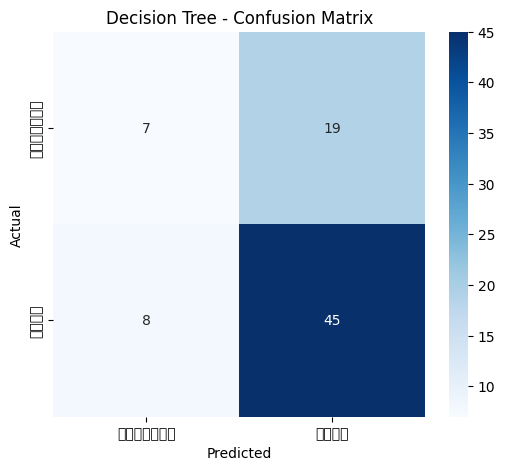

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["ไม่ผ่าน", "ผ่าน"],
    yticklabels=["ไม่ผ่าน", "ผ่าน"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree - Confusion Matrix")

plt.show()

In [22]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_dt,
    target_names=["ไม่ผ่าน", "ผ่าน"]
))

              precision    recall  f1-score   support

     ไม่ผ่าน       0.47      0.27      0.34        26
        ผ่าน       0.70      0.85      0.77        53

    accuracy                           0.66        79
   macro avg       0.58      0.56      0.56        79
weighted avg       0.63      0.66      0.63        79



In [23]:
from sklearn.neighbors import KNeighborsClassifier

knn = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]
)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

print("KNN")
print("--------------------")
print(f"Accuracy : {accuracy_knn * 100:.2f}%")
print(f"Precision: {precision_knn * 100:.2f}%")
print(f"Recall   : {recall_knn * 100:.2f}%")
print(f"F1-Score : {f1_knn * 100:.2f}%")

KNN
--------------------
Accuracy : 58.23%
Precision: 66.13%
Recall   : 77.36%
F1-Score : 71.30%


In [24]:
from sklearn.svm import SVC

svm = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", SVC(kernel="rbf", random_state=42))
    ]
)

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print("SVM")
print("--------------------")
print(f"Accuracy : {accuracy_svm * 100:.2f}%")
print(f"Precision: {precision_svm * 100:.2f}%")
print(f"Recall   : {recall_svm * 100:.2f}%")
print(f"F1-Score : {f1_svm * 100:.2f}%")

SVM
--------------------
Accuracy : 68.35%
Precision: 70.59%
Recall   : 90.57%
F1-Score : 79.34%


In [25]:
from sklearn.ensemble import RandomForestClassifier

random_forest = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ]
)

random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest")
print("--------------------")
print(f"Accuracy : {accuracy_rf * 100:.2f}%")
print(f"Precision: {precision_rf * 100:.2f}%")
print(f"Recall   : {recall_rf * 100:.2f}%")
print(f"F1-Score : {f1_rf * 100:.2f}%")

Random Forest
--------------------
Accuracy : 62.03%
Precision: 67.16%
Recall   : 84.91%
F1-Score : 75.00%


In [26]:
results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "KNN",
        "SVM",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_dt,
        accuracy_knn,
        accuracy_svm,
        accuracy_rf
    ],
    "Precision": [
        precision_dt,
        precision_knn,
        precision_svm,
        precision_rf
    ],
    "Recall": [
        recall_dt,
        recall_knn,
        recall_svm,
        recall_rf
    ],
    "F1-Score": [
        f1_dt,
        f1_knn,
        f1_svm,
        f1_rf
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.658228,0.703125,0.849057,0.769231
1,KNN,0.582278,0.661290,0.773585,0.713043
2,SVM,0.683544,0.705882,0.905660,0.793388
3,Random Forest,0.620253,0.671642,0.849057,0.750000


In [27]:
results_display = results.copy()

for col in ["Accuracy", "Precision", "Recall", "F1-Score"]:
    results_display[col] = (
        results_display[col] * 100
    ).round(2)

results_display

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,65.82,70.31,84.91,76.92
1,KNN,58.23,66.13,77.36,71.30
2,SVM,68.35,70.59,90.57,79.34
3,Random Forest,62.03,67.16,84.91,75.00


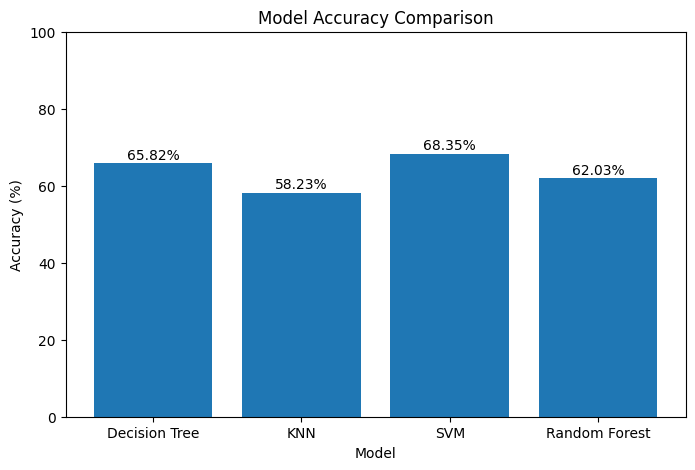

In [28]:
import matplotlib.pyplot as plt

models = results_display["Model"]
accuracy = results_display["Accuracy"]

plt.figure(figsize=(8, 5))

bars = plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

for bar, value in zip(bars, accuracy):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()

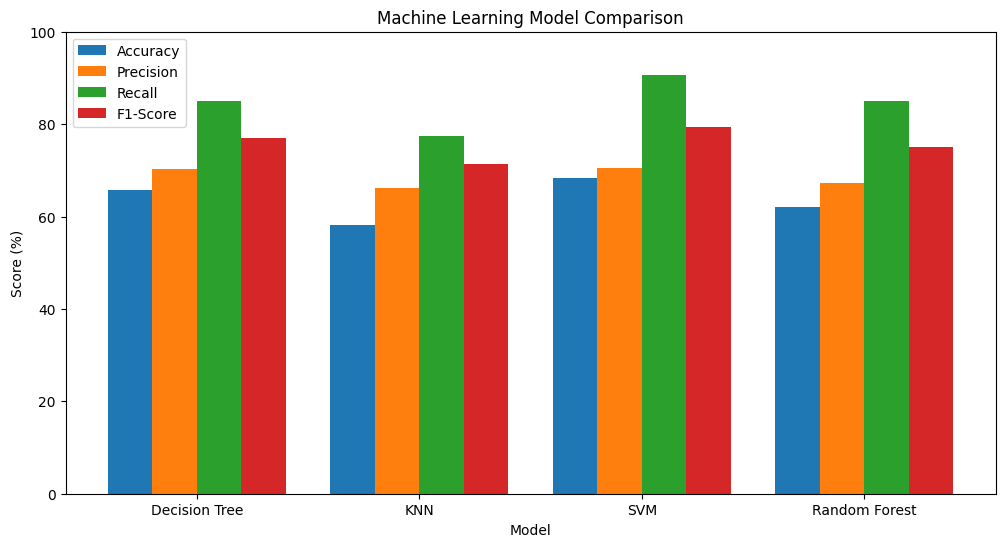

In [30]:
import numpy as np
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

models = results_display["Model"]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(12, 6))

for i, metric in enumerate(metrics):
    values = results_display[metric]

    plt.bar(
        x + (i - 1.5) * width,
        values,
        width,
        label=metric
    )

plt.xticks(x, models)
plt.ylabel("Score (%)")
plt.xlabel("Model")
plt.title("Machine Learning Model Comparison")
plt.ylim(0, 100)
plt.legend()

plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3652 (\N{THAI CHARACTER SARA AI MAIMALAI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3612 (\N{THAI CHARACTER PHO PHUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  fig.

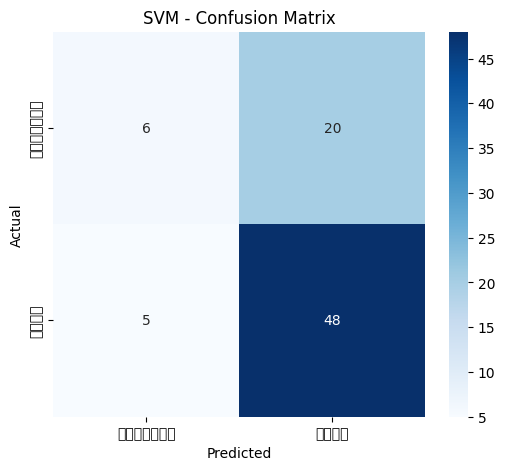

In [31]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["ไม่ผ่าน", "ผ่าน"],
    yticklabels=["ไม่ผ่าน", "ผ่าน"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM - Confusion Matrix")

plt.show()

In [32]:
import joblib

joblib.dump(svm, "student_performance_svm.pkl")

print("บันทึกโมเดลเรียบร้อยแล้ว")

บันทึกโมเดลเรียบร้อยแล้ว


In [33]:
import os

print(os.path.getsize("student_performance_svm.pkl"), "bytes")

129261 bytes


In [34]:
from google.colab import files

files.download("student_performance_svm.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
print(X.columns.tolist())

['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']


In [36]:
import sklearn
import joblib
import sys

print("Python:", sys.version)
print("scikit-learn:", sklearn.__version__)
print("joblib:", joblib.__version__)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
scikit-learn: 1.6.1
joblib: 1.5.3
